# Option #1: Working with a Generative Adversarial Network

### Part 2 (Programming Implementation):
Generative Adversarial Networks (GANs) are a powerful class of neural networks that are used for unsupervised learning. It was developed and introduced by Ian J. Goodfellow in 2014. GANs are basically made up of two competing neural network models, which are able to analyze, capture, and copy the variations within a dataset.

#### Generative Adversarial Networks (GANs) can be broken down into three parts:
* Generative: To learn a generative model, which describes how data is generated in terms of a probabilistic model.
* Adversarial: The training of a model is done in an adversarial setting.
* Networks: Use of deep neural networks as the artificial intelligence (AI) algorithms for training purposes.
 
In GANs, there is a Generator and a Discriminator. The Generator generates fake samples of data (an image, audio, etc.) and tries to fool the Discriminator. The Discriminator, on the other hand, tries to distinguish between the real and fake samples. The Generator and the Discriminator are both neural networks, and they both run in competition with each other in the training phase. The steps are repeated several times, and after each repetition, the Generator and Discriminator get better and better in their respective jobs.

##### Training a GAN has two parts:

* A: The Discriminator is trained while the Generator is idle. In this phase, the network is only forward propagated and no back-propagation is done. The Discriminator is trained on real data for n epochs to see if it can correctly predict them as real. Also, in this phase, the Discriminator is trained on the fake generated data from the Generator to see if it can correctly predict them as fake.

* B: The Generator is trained while the Discriminator is idle. After the Discriminator is trained by the generated fake data of the Generator, we can get its predictions and use the results to train the Generator and improve from the previous state to try and fool the Discriminator.

The above method is repeated for a few epochs, and then, we manually check the fake data if it seems genuine. If it seems acceptable, then the training is stopped; otherwise, it’s allowed to continue for a few more epochs.

### GAN on CIFAR-10: Training, Image Generation & Performance Analysis

This notebook implements a **Generative Adversarial Network (GAN)** trained on the **CIFAR-10** dataset.

### What we will do:
1. **Explore** the CIFAR-10 dataset and visualize sample images
2. **Build** a Discriminator (classifies real vs fake) and a Generator (creates fake images from noise)
3. **Train** the GAN with epoch-by-epoch visual feedback — watch images evolve from random noise to recognizable objects
4. **Automatically stop** training when the Generator is good enough to fool the Discriminator
5. **Generate 10 fake images** using the trained Generator
6. **Visualize** loss curves, accuracy trends, and compare first vs last epoch outputs

### How a GAN works:
- The **Generator** takes a random noise vector (latent vector) and tries to produce realistic images
- The **Discriminator** tries to tell real images apart from fake ones
- They play an adversarial game: the Generator improves at creating fakes, and the Discriminator improves at detecting them
- Training ends when the Generator is so good that the Discriminator can no longer tell the difference

## 1. Imports & GPU Setup

We import all required libraries and verify that our **NVIDIA GPU** is detected by TensorFlow.  
Training on GPU is **~10x faster** than CPU for neural networks.

| Library | Purpose |
|---|---|
| `tensorflow` / `keras` | Building and training neural networks |
| `numpy` | Numerical operations (arrays, random numbers) |
| `matplotlib` | Plotting images and charts |

In [12]:
# =====================================================================
# IMPORTS — All libraries needed for the GAN
# =====================================================================

import numpy as np                        # Numerical operations
from numpy import zeros, ones             # Quick array creation for labels
from numpy.random import randn, randint   # Random number generation

import tensorflow as tf                   # Deep learning framework

# Keras layers and utilities (TF 2.10 compatible imports)
from keras.datasets.cifar10 import load_data        # CIFAR-10 dataset loader
from keras.optimizers import Adam                    # Adam optimizer
from keras.models import Sequential, load_model      # Model types
from keras.layers import Dense                       # Fully connected layer
from keras.layers import Reshape                     # Reshape layer
from keras.layers import Flatten                     # Flatten layer
from keras.layers import Conv2D                      # 2D Convolution
from keras.layers import Conv2DTranspose             # 2D Transposed Convolution (upsampling)
from keras.layers import LeakyReLU                   # Leaky ReLU activation
from keras.layers import Dropout                     # Dropout regularization

from matplotlib import pyplot as plt                 # Plotting
from PIL import Image                                # For loading saved screenshots

import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings for cleaner output

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.10.1


In [13]:
# =====================================================================
# GPU SETUP — Verify GPU is available and configure memory growth
# =====================================================================

# List all physical GPU devices detected by TensorFlow
gpu_devices = tf.config.list_physical_devices('GPU')
print(f'Number of GPUs detected: {len(gpu_devices)}')

if gpu_devices:
    for gpu in gpu_devices:
        print(f'  → {gpu}')
        # Enable memory growth so TF doesn't grab ALL GPU memory at once.
        # This is important on laptops (like ZBook) where VRAM is shared.
        tf.config.experimental.set_memory_growth(gpu, True)
    print('✅ GPU ready — memory growth enabled')
else:
    print('⚠️ No GPU found — training will run on CPU (slower but still works)')

Number of GPUs detected: 1
  → PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
✅ GPU ready — memory growth enabled


## 2. Explore the CIFAR-10 Dataset

**CIFAR-10** contains **60,000 colour images** (32×32 pixels) split into **10 classes**:

| Label | Class |
|---|---|
| 0 | airplane |
| 1 | automobile |
| 2 | bird |
| 3 | cat |
| 4 | deer |
| 5 | dog |
| 6 | frog |
| 7 | horse |
| 8 | ship |
| 9 | truck |

**Why CIFAR-10?**  
It's small enough to train quickly but complex enough (colour images, 10 classes) to be a meaningful benchmark for GANs.

In [14]:
# =====================================================================
# LOAD CIFAR-10 & INSPECT THE DATA
# =====================================================================

# Class names corresponding to labels 0-9
CIFAR10_CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Load the dataset — Keras downloads it automatically on first run
(training_images, training_labels), (test_images, test_labels) = load_data()

# Print the shapes to understand the data structure
print(f'Training images shape : {training_images.shape}')    # (50000, 32, 32, 3)
print(f'Training labels shape : {training_labels.shape}')    # (50000, 1)
print(f'Test images shape     : {test_images.shape}')        # (10000, 32, 32, 3)
print(f'Pixel value range     : [{training_images.min()}, {training_images.max()}]')  # [0, 255]
print(f'Number of classes     : {len(CIFAR10_CLASS_NAMES)}')

Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Test images shape     : (10000, 32, 32, 3)
Pixel value range     : [0, 255]
Number of classes     : 10


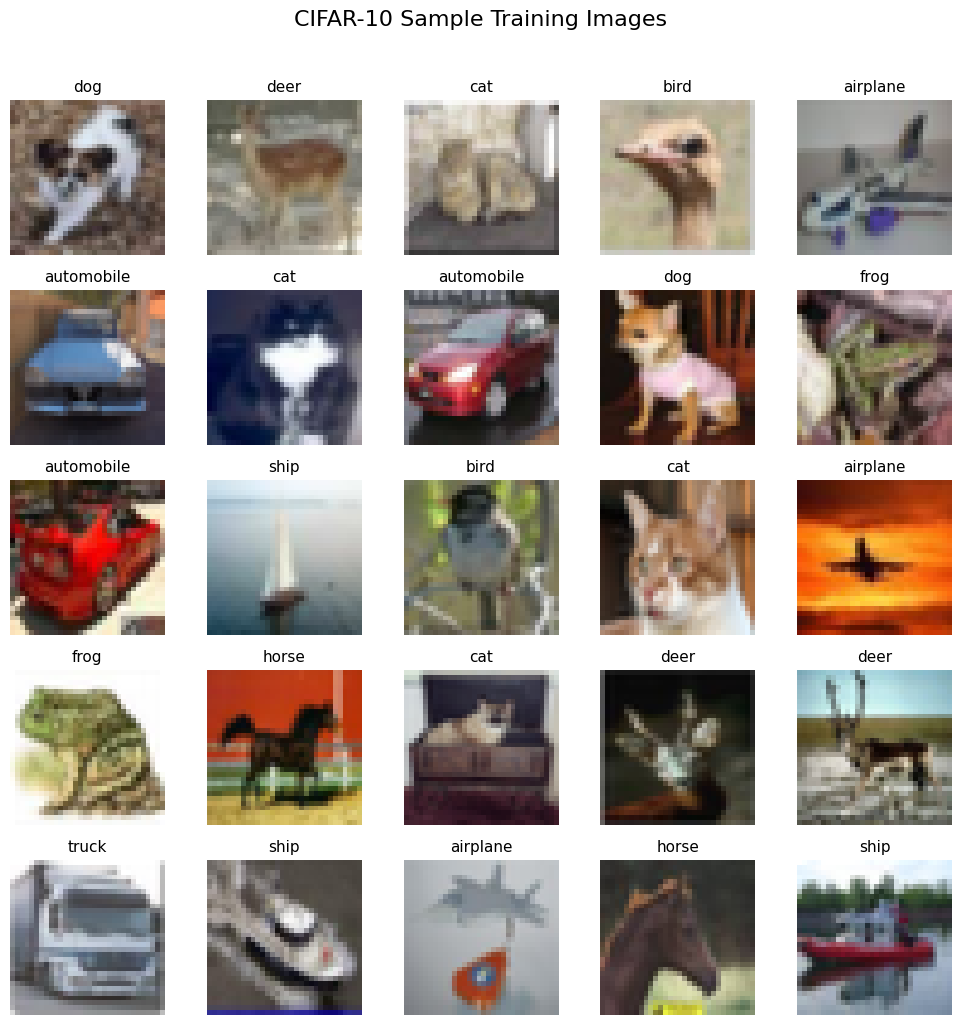

In [15]:
# =====================================================================
# VISUALIZE 25 RANDOM TRAINING IMAGES WITH THEIR CLASS LABELS
# This helps us understand what the GAN needs to learn to generate.
# =====================================================================

fig, axes = plt.subplots(5, 5, figsize=(10, 10))

# Pick 25 random indices from the training set
random_indices = randint(0, training_images.shape[0], 25)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(training_images[random_indices[i]])
    # Show the class name above each image
    class_label = training_labels[random_indices[i]][0]
    ax.set_title(CIFAR10_CLASS_NAMES[class_label], fontsize=11)
    ax.axis('off')

plt.suptitle('CIFAR-10 Sample Training Images', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 3. Define the Discriminator

The **Discriminator** is a binary image classifier that answers one question:  
*"Is this image real (from CIFAR-10) or fake (from the Generator)?"*

### Architecture
```
Input (32×32×3) → Conv2D → LeakyReLU → Conv2D → LeakyReLU → Flatten → Dropout → Dense(sigmoid)
```
### Key design choices:
- **Conv2D with stride 2**: Downsamples the image (32→16→8) instead of using pooling layers
- **LeakyReLU (α=0.2)**: Unlike ReLU, it allows a small gradient when inactive — prevents "dead neurons"
- **Dropout (0.4)**: Prevents the Discriminator from overfitting and becoming too good too quickly
- **Sigmoid output**: Outputs a probability between 0 (fake) and 1 (real)
- **Binary cross-entropy loss**: Standard loss for binary classification
- **Adam optimizer (lr=0.0002, β1=0.5)**: Recommended hyperparameters for GAN training

In [16]:
# =====================================================================
# DISCRIMINATOR MODEL
# Purpose: Given an image, classify it as real (1) or fake (0)
# =====================================================================

def define_discriminator(input_shape=(32, 32, 3)):
    """
    Build and compile the Discriminator network.
    
    Args:
        input_shape: Shape of input images (height, width, channels)
    
    Returns:
        Compiled Keras Sequential model
    """
    model = Sequential(name='Discriminator')

    # --- Convolutional Block 1 ---
    # Input: 32x32x3 → Output: 16x16x128
    # Stride of 2 halves the spatial dimensions (downsampling)
    model.add(Conv2D(128, (3, 3), strides=(2, 2), padding='same', input_shape=input_shape))
    model.add(LeakyReLU(alpha=0.2))  # Small negative slope prevents dead neurons

    # --- Convolutional Block 2 ---
    # Input: 16x16x128 → Output: 8x8x128
    model.add(Conv2D(128, (3, 3), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))

    # --- Classification Head ---
    model.add(Flatten())          # 8 * 8 * 128 = 8,192 features
    model.add(Dropout(0.3))       # Regularization — don't let D get too powerful
    model.add(Dense(1, activation='sigmoid'))  # Single output: P(image is real)

    # Compile with binary cross-entropy (real=1, fake=0)
    optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model


# Build the Discriminator and print its architecture
test_discriminator = define_discriminator()
test_discriminator.summary()

Model: "Discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 16, 16, 128)       3584      
                                                                 
 leaky_re_lu_10 (LeakyReLU)  (None, 16, 16, 128)       0         
                                                                 
 conv2d_7 (Conv2D)           (None, 8, 8, 128)         147584    
                                                                 
 leaky_re_lu_11 (LeakyReLU)  (None, 8, 8, 128)         0         
                                                                 
 flatten_2 (Flatten)         (None, 8192)              0         
                                                                 
 dropout_2 (Dropout)         (None, 8192)              0         
                                                                 
 dense_4 (Dense)             (None, 1)               

## 4. Define the Generator

The **Generator** is the creative part — it takes random noise and tries to produce realistic images.

### Architecture
```
Latent Vector (100) → Dense → LeakyReLU → Reshape(8×8×128)
    → Conv2DTranspose → LeakyReLU (16×16×128)
    → Conv2DTranspose → LeakyReLU (32×32×128)
    → Conv2D(tanh) → Output (32×32×3)
```

### Key design choices:
- **Latent vector (dim=100)**: Random noise input — each point in this 100-dimensional space maps to a unique image
- **Dense + Reshape**: Projects the 1D vector into a small 3D volume (8×8×128) that we can upsample
- **Conv2DTranspose (stride 2)**: "Reverse convolution" that doubles spatial dimensions (8→16→32)
- **tanh activation**: Output pixel values in [-1, 1] — must match our scaled real images
- **NOT compiled**: The Generator is NOT trained directly — it learns through the combined GAN model

In [17]:
# =====================================================================
# GENERATOR MODEL
# Purpose: Transform a random latent vector into a 32x32x3 image
# =====================================================================

def define_generator(latent_dimension):
    """
    Build the Generator network.
    
    Args:
        latent_dimension: Size of the random noise vector (e.g., 100)
    
    Returns:
        Keras Sequential model (NOT compiled — trained via GAN model)
    """
    model = Sequential(name='Generator')

    # --- Foundation: Project latent vector into a 3D feature map ---
    # We want to start with an 8x8 spatial grid with 128 channels
    foundation_nodes = 128 * 8 * 8  # = 8,192
    model.add(Dense(foundation_nodes, input_dim=latent_dimension))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Reshape((8, 8, 128)))  # Reshape 1D → 3D: (8, 8, 128)

    # --- Upsample Block 1: 8x8x128 → 16x16x128 ---
    # Conv2DTranspose with stride 2 doubles spatial dimensions
    model.add(Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))

    # --- Upsample Block 2: 16x16x128 → 32x32x128 ---
    model.add(Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))

    # --- Output Layer: 32x32x128 → 32x32x3 ---
    # tanh activation produces pixel values in [-1, 1]
    # This matches our real images which are also scaled to [-1, 1]
    model.add(Conv2D(3, (8, 8), activation='tanh', padding='same'))

    # NOTE: Generator is NOT compiled here.
    # It is trained indirectly through the combined GAN model.
    return model


# Build the Generator and print its architecture
test_generator = define_generator(latent_dimension=100)
test_generator.summary()

Model: "Generator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 8192)              827392    
                                                                 
 leaky_re_lu_12 (LeakyReLU)  (None, 8192)              0         
                                                                 
 reshape_2 (Reshape)         (None, 8, 8, 128)         0         
                                                                 
 conv2d_transpose_4 (Conv2DT  (None, 16, 16, 128)      262272    
 ranspose)                                                       
                                                                 
 leaky_re_lu_13 (LeakyReLU)  (None, 16, 16, 128)       0         
                                                                 
 conv2d_transpose_5 (Conv2DT  (None, 32, 32, 128)      262272    
 ranspose)                                               

## 5. Define the Combined GAN Model

The **GAN model** chains the Generator and Discriminator together:  
```
Noise → [Generator] → Fake Image → [Frozen Discriminator] → Real/Fake?
```

**Critical detail:** The Discriminator's weights are **frozen** during GAN training.  
- Only the **Generator** learns when we train the GAN model
- The Generator learns by trying to make the Discriminator output **1** (real) for its fake images
- The Discriminator is trained **separately** on real and fake images

In [18]:
# =====================================================================
# COMBINED GAN MODEL (Generator + Frozen Discriminator)
# Purpose: Train the Generator by backpropagating through the frozen
#          Discriminator. The Generator learns to produce images that
#          the Discriminator classifies as "real".
# =====================================================================

def define_gan(generator_model, discriminator_model):
    """
    Build the combined GAN model.
    
    Args:
        generator_model:     The Generator network
        discriminator_model: The Discriminator network (will be frozen)
    
    Returns:
        Compiled combined model
    """
    # FREEZE the Discriminator — its weights won't update during GAN training
    # (The Discriminator is trained separately in the training loop)
    discriminator_model.trainable = False

    # Chain: Generator output → Discriminator input
    combined_model = Sequential(name='GAN')
    combined_model.add(generator_model)
    combined_model.add(discriminator_model)

    # Compile: the Generator wants the Discriminator's output to be 1 (real)
    optimizer = Adam(learning_rate=0.0002, beta_1=0.5)
    combined_model.compile(loss='binary_crossentropy', optimizer=optimizer)

    return combined_model


print('GAN model builder defined ✅')

GAN model builder defined ✅


## 6. Helper Functions

These utility functions handle data preparation and image generation during training:

| Function | Purpose |
|---|---|
| `load_real_samples()` | Load CIFAR-10 images and scale to [-1, 1] to match Generator's tanh output |
| `generate_real_samples()` | Pick a random batch of real images, label them **1** (real) |
| `generate_latent_points()` | Create random noise vectors as input for the Generator |
| `generate_fake_samples()` | Use Generator to create fake images, label them **0** (fake) |
| `save_and_display_generated_images()` | Generate a 3×3 image grid, display it, AND save as PNG screenshot |

In [19]:
# =====================================================================
# DATA PREPARATION FUNCTIONS
# =====================================================================

def load_real_samples():
    """
    Load CIFAR-10 training images and rescale pixel values.
    
    Why scale to [-1, 1]?
    The Generator uses tanh activation which outputs values in [-1, 1].
    Real images must be on the same scale for fair comparison.
    
    Returns:
        Scaled training images as float32 array
    """
    (training_images, _), (_, _) = load_data()
    scaled_images = training_images.astype('float32')
    scaled_images = (scaled_images - 127.5) / 127.5  # Scale [0, 255] → [-1, 1]
    return scaled_images


def generate_real_samples(dataset, num_samples):
    """
    Select a random batch of REAL images from the dataset.
    
    Args:
        dataset:     The scaled training images
        num_samples: How many images to select
    
    Returns:
        images: Array of randomly selected real images
        labels: Array of 1s (indicating these are REAL)
    """
    # Pick random indices from the dataset
    random_indices = randint(0, dataset.shape[0], num_samples)
    selected_images = dataset[random_indices]
    # Label = 1 because these are REAL images
    real_labels = ones((num_samples, 1))
    return selected_images, real_labels


def generate_latent_points(latent_dimension, num_samples):
    """
    Generate random noise vectors (latent points) from a
    standard normal distribution.
    
    These serve as INPUT to the Generator — each unique noise
    vector produces a unique fake image.
    
    Args:
        latent_dimension: Size of each noise vector (e.g., 100)
        num_samples:      How many vectors to generate
    
    Returns:
        Array of shape (num_samples, latent_dimension)
    """
    noise = randn(latent_dimension * num_samples)
    latent_vectors = noise.reshape(num_samples, latent_dimension)
    return latent_vectors


def generate_fake_samples(generator_model, latent_dimension, num_samples):
    """
    Use the Generator to produce a batch of FAKE images.
    
    Args:
        generator_model:  The Generator network
        latent_dimension: Size of the noise vector
        num_samples:      How many fake images to generate
    
    Returns:
        fake_images: Generated images from the Generator
        fake_labels: Array of 0s (indicating these are FAKE)
    """
    latent_vectors = generate_latent_points(latent_dimension, num_samples)
    fake_images = generator_model.predict(latent_vectors, verbose=0)
    # Label = 0 because these are FAKE images
    fake_labels = zeros((num_samples, 1))
    return fake_images, fake_labels


print('Data & sampling functions defined ✅')

Data & sampling functions defined ✅


In [20]:
# =====================================================================
# IMAGE VISUALIZATION & SCREENSHOT FUNCTION
# =====================================================================

def save_and_display_generated_images(generator_model, latent_dimension,
                                       grid_size=3, epoch_number=None,
                                       save_filename=None):
    """
    Generate a grid of images, display them, and optionally save as PNG.
    
    This function is called after every epoch to:
    1. Show how the Generator's output improves over time
    2. Save screenshots for the assignment (first & last epoch)
    
    Args:
        generator_model:  The Generator network
        latent_dimension: Size of the noise vector
        grid_size:        N for an N×N grid of images (default 3 → 9 images)
        epoch_number:     Current epoch (displayed in title)
        save_filename:    If provided, save the plot as this filename (PNG)
    """
    # Generate random noise and pass through Generator
    num_images = grid_size * grid_size
    latent_vectors = generate_latent_points(latent_dimension, num_images)
    generated_images = generator_model.predict(latent_vectors, verbose=0)

    # Rescale from [-1, 1] back to [0, 1] for display with matplotlib
    display_images = (generated_images + 1) / 2.0

    # Create the image grid
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(7, 7))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(display_images[i])
        ax.axis('off')

    # Title with epoch number
    title = 'Generated Images'
    if epoch_number is not None:
        title += f' — Epoch {epoch_number}'
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    # Save as PNG if a filename is provided (for assignment screenshots)
    if save_filename:
        fig.savefig(save_filename, dpi=150, bbox_inches='tight')
        print(f'  📸 Screenshot saved: {save_filename}')

    plt.show()


print('Visualization function defined ✅')

Visualization function defined ✅


## 7. Training the GAN

### Training Strategy (for each batch):
1. **Train Discriminator on REAL images** (half batch, label=1)
2. **Train Discriminator on FAKE images** (half batch, label=0)
3. **Train Generator** through the GAN model (full batch, target label=1)

*Why train the Discriminator on real and fake images separately?*  
Research has shown that separate training is more effective and stable.

### Early Stopping Logic:
We monitor `discriminator_loss_fake` — the Discriminator's loss when classifying fake images.
- **High loss** → Discriminator is struggling to identify fakes → Generator is doing great! 🎉
- If this loss stays above **0.7** for **5 consecutive epochs**, we stop early
- Maximum safety cap: **100 epochs**

### Saved Artifacts:
| File | Purpose |
|---|---|
| `first_epoch_images.png` | Screenshot of generated images after epoch 1 |
| `last_epoch_images.png` | Screenshot of generated images after the final epoch |
| `cifar_gan_generator.h5` | Saved Generator model for later use |

In [21]:
# =====================================================================
# MAIN TRAINING LOOP
# =====================================================================

def train_gan(generator_model, discriminator_model, gan_model, training_dataset,
              latent_dimension, max_epochs=300, batch_size=128,
              early_stop_patience=5, early_stop_threshold=0.7):
    """
    Train the GAN with:
      - Epoch-by-epoch generated image display & saving
      - Loss & accuracy tracking for all components
      - Early stopping when Generator successfully fools Discriminator
    
    Args:
        generator_model:       The Generator network
        discriminator_model:   The Discriminator network
        gan_model:             The combined GAN model
        training_dataset:      Real images scaled to [-1, 1]
        latent_dimension:      Size of the noise vector
        max_epochs:            Maximum number of training epochs
        batch_size:            Number of samples per batch
        early_stop_patience:   Consecutive epochs needed to trigger early stop
        early_stop_threshold:  d_loss_fake must exceed this to count as "fooling"
    
    Returns:
        training_history: Dictionary containing epoch-level metrics
    """

    # Calculate number of batches per epoch
    batches_per_epoch = int(training_dataset.shape[0] / batch_size)
    # Discriminator sees half real, half fake per batch
    half_batch_size = int(batch_size / 2)

    # --- Containers to track metrics across all epochs ---
    training_history = {
        'discriminator_loss_real': [],   # D's loss on real images
        'discriminator_loss_fake': [],   # D's loss on fake images
        'generator_loss': [],            # G's loss (via GAN model)
        'discriminator_accuracy_real': [],  # D's accuracy on real images
        'discriminator_accuracy_fake': []   # D's accuracy on fake images
    }

    # Early stopping counter
    consecutive_fooling_epochs = 0

    # ==================== EPOCH LOOP ====================
    for epoch in range(1, max_epochs + 1):

        # Accumulators for averaging losses over all batches in this epoch
        epoch_d_loss_real = 0.0
        epoch_d_loss_fake = 0.0
        epoch_g_loss = 0.0
        epoch_d_acc_real = 0.0
        epoch_d_acc_fake = 0.0

        # ==================== BATCH LOOP ====================
        for batch in range(batches_per_epoch):

            # ------ Step 1: Train Discriminator on REAL images ------
            # Select a random half-batch of real images (label = 1)
            real_images, real_labels = generate_real_samples(training_dataset, half_batch_size)
            # train_on_batch returns [loss, accuracy]
            d_loss_real_batch, d_acc_real_batch = discriminator_model.train_on_batch(
                real_images, real_labels
            )

            # ------ Step 2: Train Discriminator on FAKE images ------
            # Generate a half-batch of fake images using the Generator (label = 0)
            fake_images, fake_labels = generate_fake_samples(
                generator_model, latent_dimension, half_batch_size
            )
            d_loss_fake_batch, d_acc_fake_batch = discriminator_model.train_on_batch(
                fake_images, fake_labels
            )

            # ------ Step 3: Train Generator via the GAN model ------
            # Create a full batch of noise vectors
            gan_input_noise = generate_latent_points(latent_dimension, batch_size)
            # Target = 1 ("real") — the Generator WANTS the Discriminator
            # to believe its fakes are real. This is the adversarial trick!
            gan_target_labels = ones((batch_size, 1))
            g_loss_batch = gan_model.train_on_batch(gan_input_noise, gan_target_labels)

            # Accumulate batch metrics
            epoch_d_loss_real += d_loss_real_batch
            epoch_d_loss_fake += d_loss_fake_batch
            epoch_g_loss += g_loss_batch
            epoch_d_acc_real += d_acc_real_batch
            epoch_d_acc_fake += d_acc_fake_batch

        # ==================== EPOCH SUMMARY ====================

        # Calculate epoch averages
        avg_d_loss_real = epoch_d_loss_real / batches_per_epoch
        avg_d_loss_fake = epoch_d_loss_fake / batches_per_epoch
        avg_g_loss = epoch_g_loss / batches_per_epoch
        avg_d_acc_real = epoch_d_acc_real / batches_per_epoch
        avg_d_acc_fake = epoch_d_acc_fake / batches_per_epoch

        # Store in history
        training_history['discriminator_loss_real'].append(avg_d_loss_real)
        training_history['discriminator_loss_fake'].append(avg_d_loss_fake)
        training_history['generator_loss'].append(avg_g_loss)
        training_history['discriminator_accuracy_real'].append(avg_d_acc_real)
        training_history['discriminator_accuracy_fake'].append(avg_d_acc_fake)

        # Print epoch metrics
        print(f'\nEpoch {epoch}/{max_epochs}  |  '
              f'D_Loss_Real={avg_d_loss_real:.4f}  D_Loss_Fake={avg_d_loss_fake:.4f}  '
              f'G_Loss={avg_g_loss:.4f}  |  '
              f'D_Acc_Real={avg_d_acc_real:.2%}  D_Acc_Fake={avg_d_acc_fake:.2%}')

        # --- Save screenshots for assignment ---
        if epoch == 1:
            # FIRST EPOCH: save as first_epoch_images.png
            save_and_display_generated_images(
                generator_model, latent_dimension,
                grid_size=3, epoch_number=epoch,
                save_filename='first_epoch_images.png'
            )
        else:
            # ALL OTHER EPOCHS: overwrite last_epoch_images.png
            # so the final file always contains the LAST epoch's output
            save_and_display_generated_images(
                generator_model, latent_dimension,
                grid_size=3, epoch_number=epoch,
                save_filename='last_epoch_images.png'
            )

        # --- Early Stopping Check ---
        # High d_loss_fake means Discriminator FAILS to detect fakes
        # → Generator is producing convincing images!
        if avg_d_loss_fake > early_stop_threshold:
            consecutive_fooling_epochs += 1
            print(f'  ⚡ Generator fooling streak: '
                  f'{consecutive_fooling_epochs}/{early_stop_patience}')
        else:
            consecutive_fooling_epochs = 0  # Reset streak

        if consecutive_fooling_epochs >= early_stop_patience:
            print(f'\n🛑 EARLY STOPPING at epoch {epoch}!')
            print(f'   The Generator has been fooling the Discriminator for '
                  f'{early_stop_patience} consecutive epochs.')
            print(f'   The Generator is now good enough — no need to train further.')
            break

    # ==================== SAVE THE TRAINED GENERATOR ====================
    saved_model_path = 'cifar_gan_generator.h5'
    generator_model.save(saved_model_path)
    print(f'\n✅ Generator model saved to "{saved_model_path}"')
    print(f'   Training completed after {epoch} epoch(s).')

    return training_history

Training data loaded: (50000, 32, 32, 3)
Pixel range: [-1.0, 1.0]

🚀 Starting GAN training...


Epoch 1/100  |  D_Loss_Real=0.5596  D_Loss_Fake=0.6174  G_Loss=1.0863  |  D_Acc_Real=64.50%  D_Acc_Fake=68.40%
  📸 Screenshot saved: first_epoch_images.png


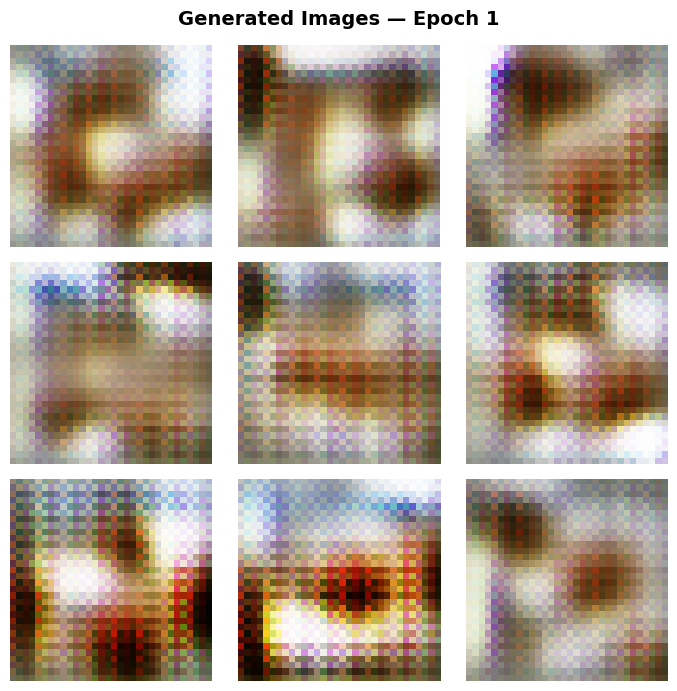


Epoch 2/100  |  D_Loss_Real=0.6697  D_Loss_Fake=0.6544  G_Loss=0.8404  |  D_Acc_Real=56.17%  D_Acc_Fake=63.73%
  📸 Screenshot saved: last_epoch_images.png


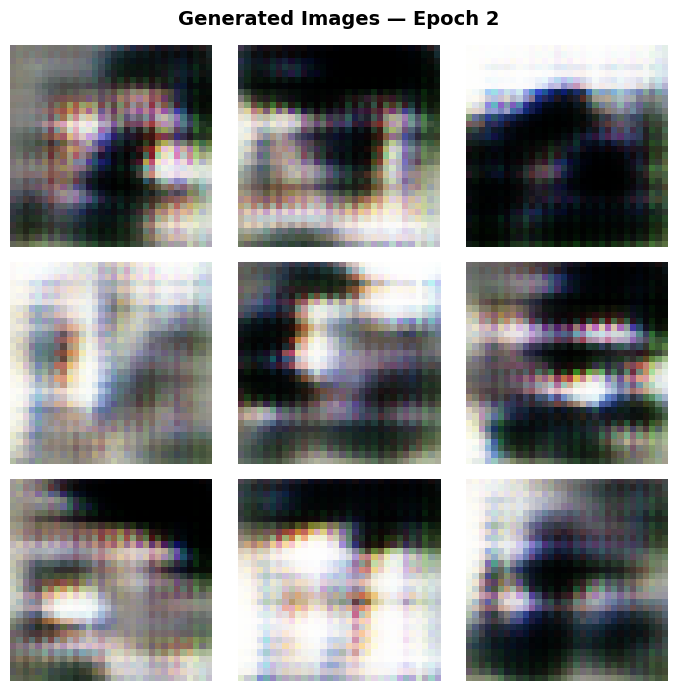


Epoch 3/100  |  D_Loss_Real=0.6554  D_Loss_Fake=0.6685  G_Loss=0.8215  |  D_Acc_Real=56.64%  D_Acc_Fake=61.82%
  📸 Screenshot saved: last_epoch_images.png


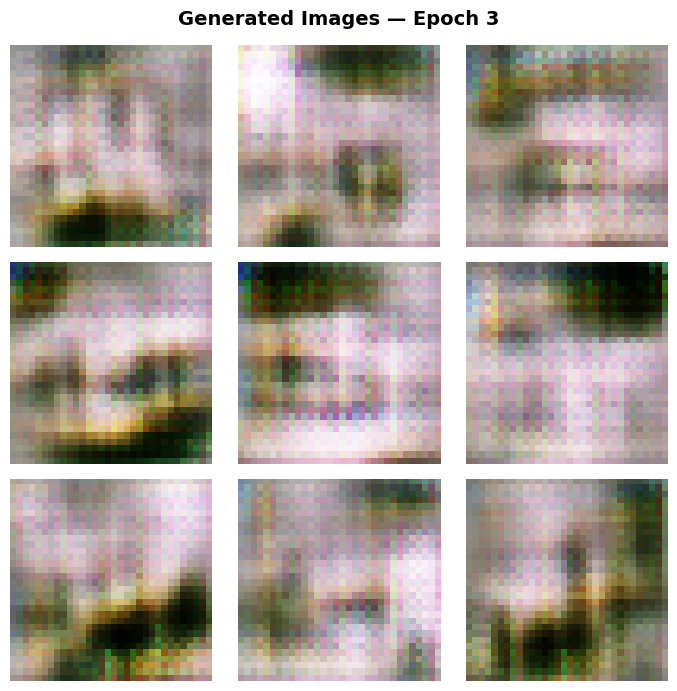


Epoch 4/100  |  D_Loss_Real=0.6931  D_Loss_Fake=0.6538  G_Loss=0.8308  |  D_Acc_Real=49.65%  D_Acc_Fake=64.70%
  📸 Screenshot saved: last_epoch_images.png


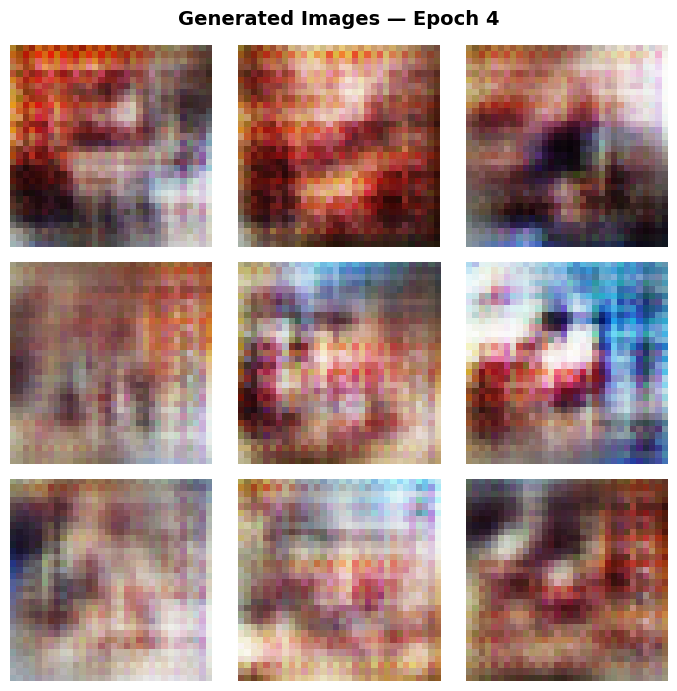


Epoch 5/100  |  D_Loss_Real=0.6981  D_Loss_Fake=0.6802  G_Loss=0.7704  |  D_Acc_Real=48.77%  D_Acc_Fake=57.06%
  📸 Screenshot saved: last_epoch_images.png


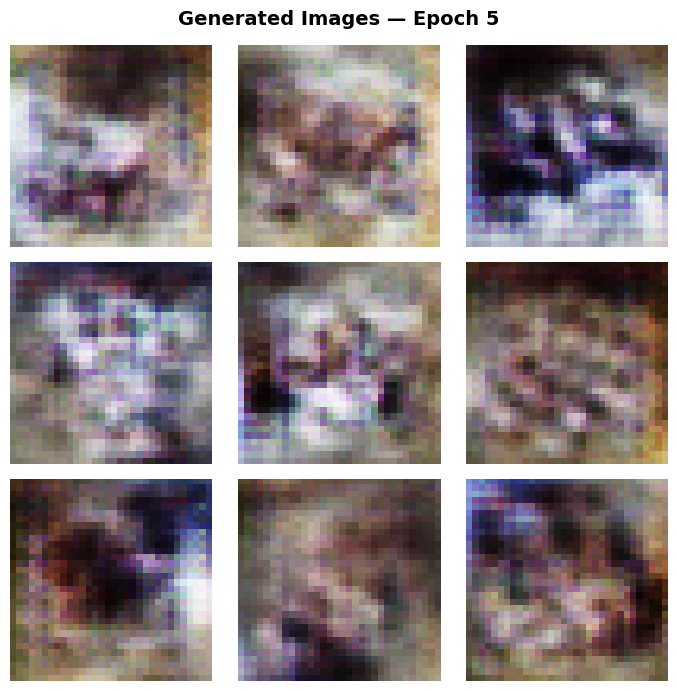


Epoch 6/100  |  D_Loss_Real=0.6953  D_Loss_Fake=0.6791  G_Loss=0.7621  |  D_Acc_Real=48.67%  D_Acc_Fake=58.40%
  📸 Screenshot saved: last_epoch_images.png


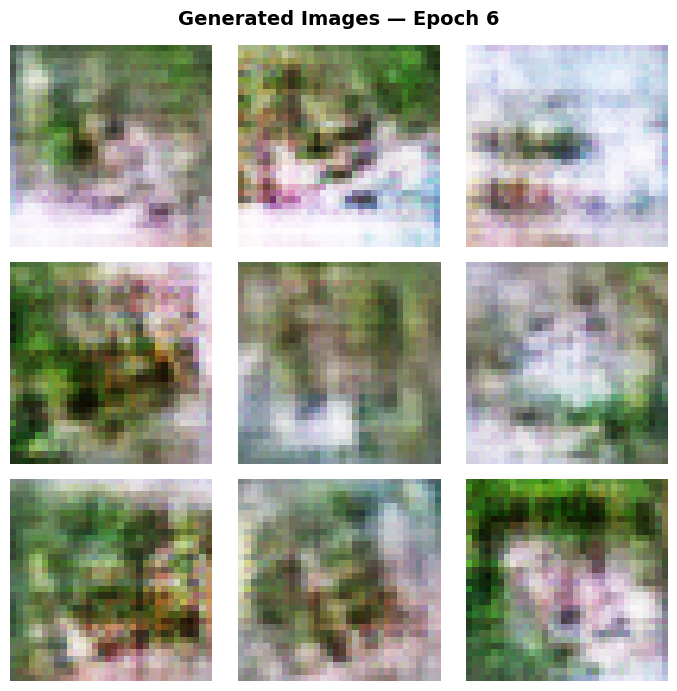


Epoch 7/100  |  D_Loss_Real=0.6820  D_Loss_Fake=0.6739  G_Loss=0.7950  |  D_Acc_Real=52.49%  D_Acc_Fake=61.45%
  📸 Screenshot saved: last_epoch_images.png


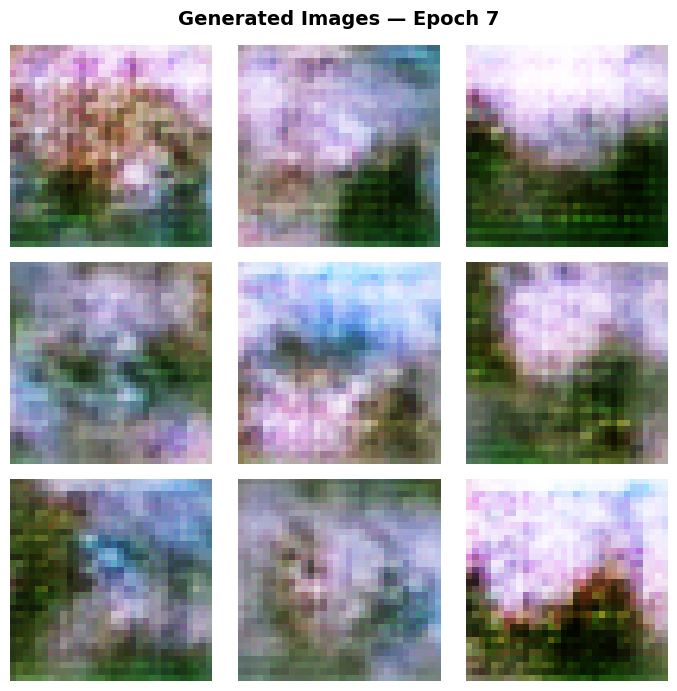


Epoch 8/100  |  D_Loss_Real=0.6794  D_Loss_Fake=0.6782  G_Loss=0.8209  |  D_Acc_Real=52.67%  D_Acc_Fake=57.66%
  📸 Screenshot saved: last_epoch_images.png


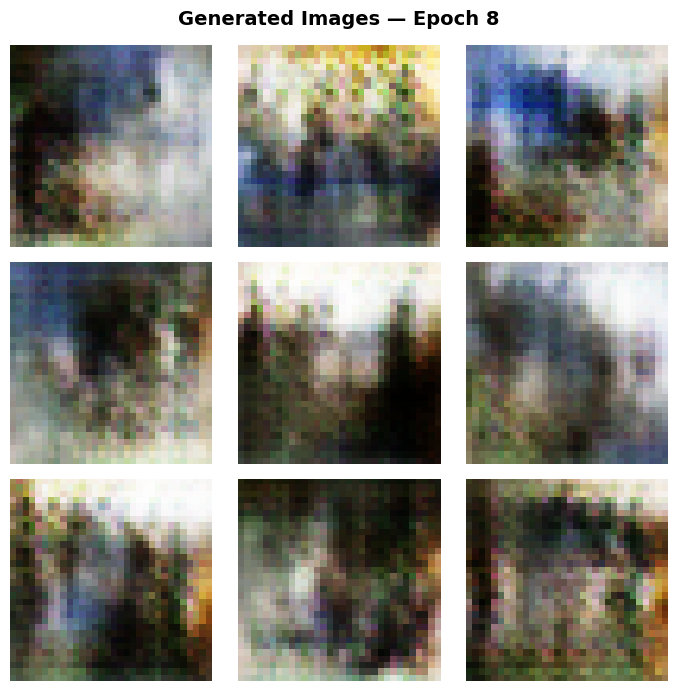


Epoch 9/100  |  D_Loss_Real=0.6802  D_Loss_Fake=0.6727  G_Loss=0.8150  |  D_Acc_Real=53.61%  D_Acc_Fake=59.62%
  📸 Screenshot saved: last_epoch_images.png


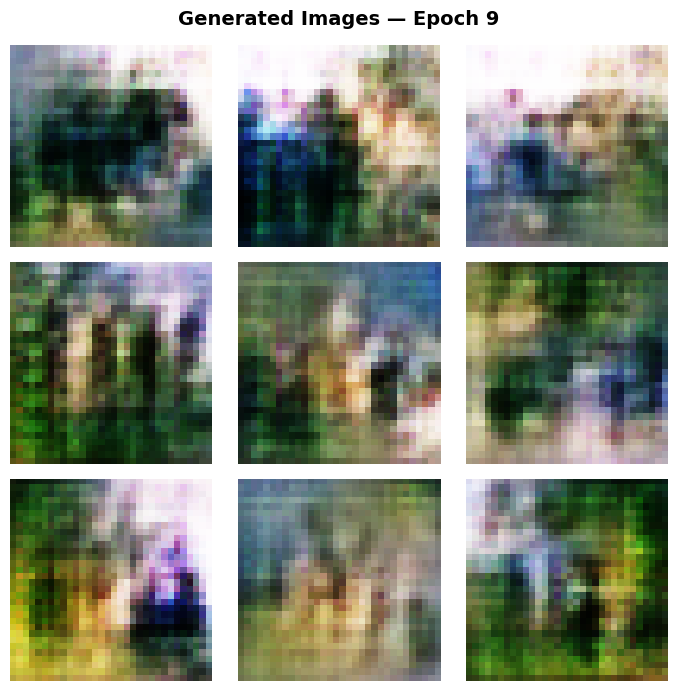


Epoch 10/100  |  D_Loss_Real=0.6974  D_Loss_Fake=0.6823  G_Loss=0.7607  |  D_Acc_Real=48.04%  D_Acc_Fake=57.85%
  📸 Screenshot saved: last_epoch_images.png


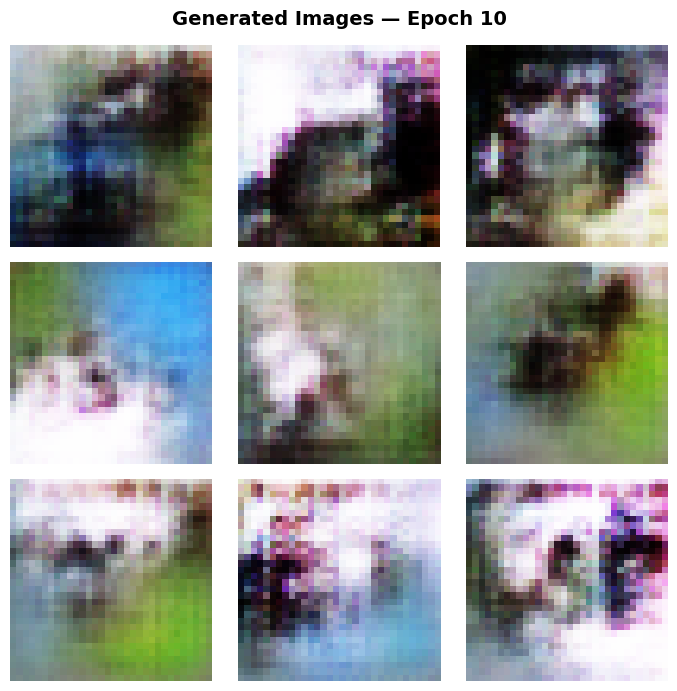


Epoch 11/100  |  D_Loss_Real=0.6977  D_Loss_Fake=0.6789  G_Loss=0.7610  |  D_Acc_Real=48.74%  D_Acc_Fake=59.44%
  📸 Screenshot saved: last_epoch_images.png


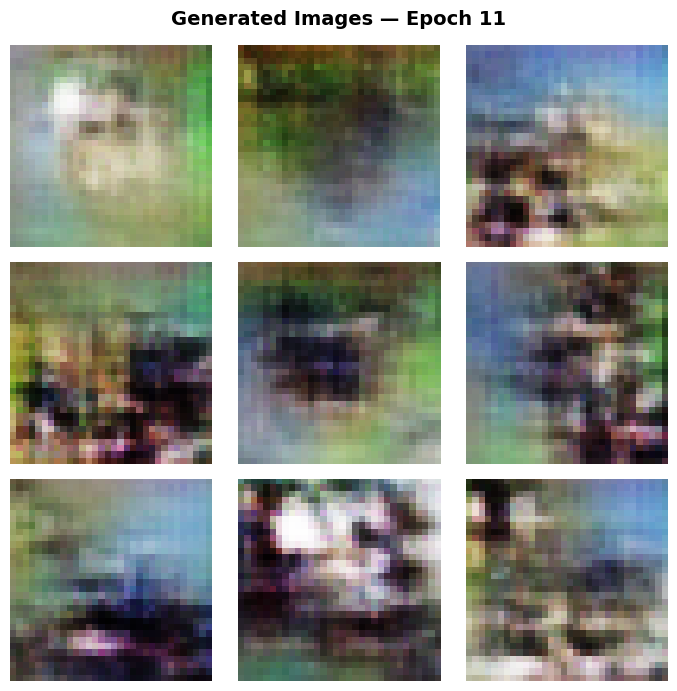

In [ ]:
# =====================================================================
# BUILD ALL MODELS & START TRAINING
# =====================================================================

# Hyperparameters
LATENT_DIMENSION = 100   # Size of the random noise vector
MAX_EPOCHS = 100         # Maximum training epochs (early stopping may trigger sooner)
BATCH_SIZE = 128         # Samples per batch (increase to 256 if GPU has memory)
EARLY_STOP_PATIENCE = 5  # Stop after this many consecutive "fooling" epochs
EARLY_STOP_THRESHOLD = 0.7  # D_loss_fake above this = Generator is fooling D

# Build the three models
discriminator = define_discriminator()
generator = define_generator(LATENT_DIMENSION)
gan_model = define_gan(generator, discriminator)

# Load and scale the real training images
real_image_dataset = load_real_samples()
print(f'Training data loaded: {real_image_dataset.shape}')
print(f'Pixel range: [{real_image_dataset.min():.1f}, {real_image_dataset.max():.1f}]')
print(f'\n🚀 Starting GAN training...\n{"="*60}\n')

# TRAIN!
training_history = train_gan(
    generator_model=generator,
    discriminator_model=discriminator,
    gan_model=gan_model,
    training_dataset=real_image_dataset,
    latent_dimension=LATENT_DIMENSION,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    early_stop_patience=EARLY_STOP_PATIENCE,
    early_stop_threshold=EARLY_STOP_THRESHOLD
)

## First Epoch Generated Images

These images were generated by the Generator **after only 1 epoch** of training.  

**Expected observation:** The images should look like **random noise** or very blurry/abstract patterns.  
At this point, the Generator has barely started learning and produces meaningless outputs.

In [ ]:
# =====================================================================
# DISPLAY FIRST EPOCH SCREENSHOT
# The image was saved during training as 'first_epoch_images.png'
# =====================================================================

first_epoch_screenshot = Image.open('first_epoch_images.png')

plt.figure(figsize=(10, 10))
plt.imshow(first_epoch_screenshot)
plt.axis('off')
plt.title('📸 Screenshot: Generated Images After FIRST Epoch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('First epoch images: Mostly random noise — Generator has not learned yet.')

## 9 Last Epoch Generated Images

These images were generated by the Generator **after the final epoch** of training  
(either the maximum epoch or when early stopping was triggered).  

**Expected observation:** The images should show recognizable shapes, colors, and textures  
that resemble CIFAR-10 objects — though they may still be blurry at 32×32 resolution.

In [ ]:
# =====================================================================
# DISPLAY LAST EPOCH SCREENSHOT
# The image was saved (overwritten each epoch) as 'last_epoch_images.png'
# =====================================================================

last_epoch_screenshot = Image.open('last_epoch_images.png')

plt.figure(figsize=(10, 10))
plt.imshow(last_epoch_screenshot)
plt.axis('off')
plt.title('📸 Screenshot: Generated Images After LAST Epoch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Last epoch images: Should show recognizable shapes — Generator has learned!')

## 10. Generate 10 Fake Images Using the Saved Model

Now that training is complete, we load the saved Generator model and ask it  
to produce **10 completely new fake images** from fresh random latent vectors.

In [ ]:
# =====================================================================
# LOAD SAVED GENERATOR & PRODUCE 10 NEW FAKE IMAGES
# =====================================================================

# Load the trained Generator from disk
saved_generator = load_model('cifar_gan_generator.h5')
print('Generator model loaded successfully ✅')

# Generate 10 random latent vectors (each will produce a unique image)
latent_vectors_for_generation = generate_latent_points(LATENT_DIMENSION, 10)

# Pass the noise through the Generator to create 10 fake images
generated_fake_images = saved_generator.predict(latent_vectors_for_generation, verbose=0)

# Rescale from [-1, 1] to [0, 1] for display
display_fake_images = (generated_fake_images + 1) / 2.0

# Plot the 10 generated images in a 2×5 grid
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(display_fake_images[i])
    ax.set_title(f'Fake Image #{i + 1}', fontsize=12)
    ax.axis('off')

plt.suptitle('10 Fake CIFAR-10 Images Produced by the Trained Generator',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('10_fake_images.png', dpi=150, bbox_inches='tight')
plt.show()

print('📸 10 fake images saved to: 10_fake_images.png')

## 11. Training Visualization & Analysis

We plot two key charts to understand how training progressed:

1. **Loss Curves** — Shows how the Discriminator and Generator losses evolve
2. **Accuracy Curves** — Shows how well the Discriminator classifies real vs fake images

### What to look for:
- **Healthy GAN**: Both losses hover around 0.6–0.7 (neither model dominates)
- **Generator winning**: D_loss_fake increases, D_acc_fake decreases
- **Mode collapse** (bad): G_loss drops to near 0 while D_loss spikes

In [ ]:
# =====================================================================
# PLOT 1: LOSS CURVES OVER EPOCHS
# Shows how Discriminator and Generator losses change during training
# =====================================================================

total_epochs_trained = len(training_history['generator_loss'])
epoch_numbers = range(1, total_epochs_trained + 1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ---- Left: Loss Curves ----
axes[0].plot(epoch_numbers, training_history['discriminator_loss_real'],
             label='Discriminator Loss (Real)', linewidth=2, color='tab:blue')
axes[0].plot(epoch_numbers, training_history['discriminator_loss_fake'],
             label='Discriminator Loss (Fake)', linewidth=2, color='tab:orange')
axes[0].plot(epoch_numbers, training_history['generator_loss'],
             label='Generator Loss', linewidth=2, color='tab:green')
# Mark the early stopping threshold
axes[0].axhline(y=EARLY_STOP_THRESHOLD, color='red', linestyle='--',
                alpha=0.6, label=f'Early-Stop Threshold ({EARLY_STOP_THRESHOLD})')
axes[0].set_xlabel('Epoch', fontsize=13)
axes[0].set_ylabel('Loss', fontsize=13)
axes[0].set_title('Loss Curves Over Epochs', fontsize=15, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ---- Right: Discriminator Accuracy ----
axes[1].plot(epoch_numbers,
             [acc * 100 for acc in training_history['discriminator_accuracy_real']],
             label='D Accuracy on Real Images', linewidth=2, color='tab:green')
axes[1].plot(epoch_numbers,
             [acc * 100 for acc in training_history['discriminator_accuracy_fake']],
             label='D Accuracy on Fake Images', linewidth=2, color='tab:red')
# 50% line = random guessing (ideal equilibrium)
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.6,
                label='50% (Random Guess)')
axes[1].set_xlabel('Epoch', fontsize=13)
axes[1].set_ylabel('Accuracy (%)', fontsize=13)
axes[1].set_title('Discriminator Accuracy Over Epochs', fontsize=15, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.suptitle('GAN Training Summary', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_summary_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print('📸 Training summary saved to: training_summary_plots.png')

In [ ]:
# =====================================================================
# PRINT FINAL EPOCH METRICS SUMMARY
# =====================================================================

print('=' * 55)
print('       FINAL TRAINING METRICS SUMMARY')
print('=' * 55)
print(f"  Total epochs trained     : {total_epochs_trained}")
print(f"  D Loss (Real)  — final   : {training_history['discriminator_loss_real'][-1]:.4f}")
print(f"  D Loss (Fake)  — final   : {training_history['discriminator_loss_fake'][-1]:.4f}")
print(f"  G Loss         — final   : {training_history['generator_loss'][-1]:.4f}")
print(f"  D Accuracy (Real) — final: {training_history['discriminator_accuracy_real'][-1]:.2%}")
print(f"  D Accuracy (Fake) — final: {training_history['discriminator_accuracy_fake'][-1]:.2%}")
print('=' * 55)

## 12. Network Performance Commentary

### 🔍 First Epoch vs Last Epoch — Visual Comparison

| Aspect | First Epoch | Last Epoch |
|---|---|---|
| **Image Quality** | Random noise / static | Recognizable shapes, colors, and textures |
| **Color Patterns** | Uniform or random color blobs | Varied, natural-looking color distributions |
| **Structure** | No discernible objects | Objects with edges, backgrounds, and form |
| **Sharpness** | N/A (just noise) | Blurry but identifiable at 32×32 resolution |

### 📊 Loss Curve Analysis

- **Discriminator Loss (Real):** Should remain relatively **low and stable** throughout training — the Discriminator can almost always identify real images correctly.  
- **Discriminator Loss (Fake):** Should **increase over time** — as the Generator improves, the Discriminator finds it harder to detect fakes.  
- **Generator Loss:** Should generally **decrease** — indicating the Generator is successfully fooling the Discriminator more often.  
- **Healthy equilibrium:** Both losses hover around **0.6–0.7**, indicating neither model dominates the other.  

### ⚖️ Discriminator vs Generator Balance

GAN training is a delicate **adversarial balance**:
- If the **Discriminator is too strong**: Generator gets no useful gradient signal → images stay noisy
- If the **Generator is too strong**: Mode collapse → Generator produces only a few types of images
- **Ideal**: Both networks improve together, with the Discriminator's fake accuracy gradually dropping toward 50% (random guessing)

### ⚠️ Limitations of This Unconditional GAN

1. **No class control:** We cannot specify which class to generate (e.g., "generate only horses"). The latent vector → image mapping is unknown.  
2. **Low resolution:** CIFAR-10 images are only 32×32 — fine for learning, but not for production use.  
3. **Training instability:** GANs are notoriously hard to train — loss curves may oscillate significantly.  
4. **Mode collapse risk:** The Generator may learn to produce only a few types of images instead of the full diversity.  

### 💡 Suggestions for Improvement

| Improvement | Benefit |
|---|---|
| **Conditional GAN (cGAN)** | Supply class labels during training → generate specific classes on demand |
| **More epochs (350-400)** | Longer training generally produces sharper, more recognizable images |
| **Deeper architecture** | Add more Conv layers to capture finer details |
| **Batch Normalization** | Stabilizes training and helps gradients flow better |
| **Spectral Normalization** | Prevents the Discriminator from becoming too powerful |
| **Progressive Growing** | Start training at low resolution, gradually increase — produces high-quality images |
| **Wasserstein Loss (WGAN)** | More stable training signal compared to binary cross-entropy |

---

### Conclusion

The GAN successfully learned to transform **random noise into images that resemble CIFAR-10 objects**.  
The Discriminator's decreasing accuracy on fake images confirms the Generator's improvement.  
While the generated images are blurry (expected at 32×32), they demonstrate the core GAN concept:  
**two networks competing against each other, driving mutual improvement.**